<a href="https://colab.research.google.com/github/nadiduno/CienciaDeDados-BootCampFly/blob/main/raspagem_da_web_pandas_beautifulsoup_scrapy_selenium.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Web Scraping with Pandas

Pandas offers a convenient `read_html()` function that can directly parse HTML tables from a URL or a string. It's often the quickest way to extract tabular data from web pages, but it might not work if the content is dynamically loaded by JavaScript or if the website has complex structures or anti-scraping measures.

O Pandas oferece uma função `read_html()` conveniente que pode analisar diretamente tabelas HTML de um URL ou de uma string. Geralmente, é a maneira mais rápida de extrair dados tabulares de páginas da web, mas pode não funcionar se o conteúdo for carregado dinamicamente por JavaScript ou se o site tiver estruturas complexas ou medidas anti-raspagem.

In [ ]:
import pandas as pd
import requests
import io

URL = 'https://en.wikipedia.org/wiki/List_of_largest_banks'

# Add a User-Agent header to mimic a web browser
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

try:
    # Fetch the HTML content using requests with the custom User-Agent
    response = requests.get(URL, headers=headers)
    response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)

    # Read the HTML content into pandas using io.StringIO
    tables = pd.read_html(io.StringIO(response.text))
    df = tables[0]
    print(df)

except requests.exceptions.HTTPError as err:
    print(f"HTTP error occurred: {err}")
except Exception as err:
    print(f"An error occurred: {err}")

    Rank                                Bank name  \
0      1  Industrial and Commercial Bank of China   
1      2               Agricultural Bank of China   
2      3                  China Construction Bank   
3      4                            Bank of China   
4      5                           JPMorgan Chase   
..   ...                                      ...   
95    96                  Caixa Econômica Federal   
96    97                                SEB Group   
97    98                          Nomura Holdings   
98    99                     First Abu Dhabi Bank   
99   100                      Qatar National Bank   

    Total assets (April 2026) (US$ billion)  
0                                   7645.80  
1                                   6974.82  
2                                   6524.05  
3                                   5484.11  
4                                   4424.90  
..                                      ...  
95                                   403.

# Web Scraping with BeautifulSoup

BeautifulSoup is a Python library for pulling data out of HTML and XML files. It creates a parse tree for parsed pages that can be used to extract data from HTML, which is useful for web scraping. While it doesn't handle HTTP requests itself (it needs libraries like `requests` for that), it's excellent for navigating and searching the parsed HTML structure.

BeautifulSoup é uma biblioteca Python para extrair dados de arquivos HTML e XML. Ela cria uma árvore de análise para páginas analisadas que pode ser usada para extrair dados de HTML, o que é útil para raspagem da web. Embora não lide com solicitações HTTP por si mesma (precisa de bibliotecas como `requests` para isso), é excelente para navegar e pesquisar a estrutura HTML analisada.

In [ ]:
from bs4 import BeautifulSoup
import requests
import pandas as pd

URL_BS = 'https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)'

# Use the same User-Agent header as before to avoid 403 Forbidden errors
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

try:
    # Fetch the HTML content
    response = requests.get(URL_BS, headers=headers)
    response.raise_for_status() # Raise an exception for HTTP errors

    # Parse the HTML content with BeautifulSoup
    soup = BeautifulSoup(response.text, 'html.parser')

    # Find all tables on the page. We know from previous attempts that the relevant table is the third one (index 2).
    tables = soup.find_all('table')
    gdp_table = tables[2] # Select the third table

    # Extract table headers
    headers_bs = []
    for th in gdp_table.find_all('th'):
        headers_bs.append(th.text.strip())

    # Extract table rows
    rows_bs = []
    for tr in gdp_table.find_all('tr')[1:]: # Skip the header row
        tds = tr.find_all('td')
        row = [td.text.strip() for td in tds]
        if row: # Only add non-empty rows
            rows_bs.append(row)

    # Create a pandas DataFrame
    # Note: Wikipedia table structure can be complex, and headers might span multiple rows.
    # For simplicity, we're taking the first set of 'th' as headers.
    # A more robust solution might involve inspecting the header rows more carefully.
    df_bs = pd.DataFrame(rows_bs)

    # Assign column names. We need to handle potential multi-level headers in Wikipedia.
    # For this specific table, inspecting the HTML or previous df2 output helps.
    # Let's try to map the known headers from df2 for better column naming.
    # The actual column names from the HTML might need cleaning (e.g., removing [1], [6], [7]).
    # Let's use a simplified approach to get column names from the first header row in the table if available.
    header_row_ths = gdp_table.find_all('tr')[0].find_all('th') # First row for headers
    if header_row_ths:
        extracted_headers = [th.text.strip() for th in header_row_ths]
        # Clean up footnotes/brackets from headers
        cleaned_headers = [h.split('[')[0].strip() for h in extracted_headers]
        # Ensure we have the correct number of columns for the DataFrame
        if len(cleaned_headers) == df_bs.shape[1]:
            df_bs.columns = cleaned_headers
        else:
            print("Warning: Number of extracted headers does not match DataFrame columns. Using default numeric columns.")

    display(df_bs.head())

except requests.exceptions.HTTPError as err:
    print(f"HTTP error occurred: {err}")
except Exception as err:
    print(f"An error occurred: {err}")

,Country/Territory,IMF(2026),World Bank(2024),United Nations(2024)
0,World,"126,295,331","111,326,370","100,834,796"
1,United States,"32,383,920","28,750,956","29,298,000"
2,China[n 1],"20,851,593","18,743,803","18,743,802"
3,Germany,"5,452,858","4,685,593","4,659,929"
4,Japan,"4,379,253","4,027,598","4,026,211"


# Web Scraping with Scrapy

Scrapy is a powerful and flexible web scraping framework. It works by sending requests, receiving responses, and then parsing the HTML content with a defined 'spider' to extract data. We'll set up a basic spider to get the bank data.

Scrapy é um framework poderoso e flexível para raspagem da web. Ele funciona enviando requisições, recebendo respostas e, em seguida, analisando o conteúdo HTML com um 'spider' definido para extrair dados. Vamos configurar um spider básico para obter os dados do banco.

In [ ]:
# Install Scrapy
!pip install scrapy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.2/47.2 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 344.3/344.3 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.7/270.7 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.9/105.9 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.6/74.6 kB 8.6 MB/s eta 0:00:00


In [ ]:
import scrapy
from scrapy.crawler import CrawlerProcess
import pandas as pd
from twisted.internet import reactor

# URL for the bank list
BANK_LIST_URL = 'https://en.wikipedia.org/wiki/List_of_largest_banks'

# Custom pipeline to store scraped items
class ItemCollectorPipeline:
    def __init__(self):
        self.items = []

    def process_item(self, item, spider):
        self.items.append(item)
        return item

# Define the Scrapy Spider
class BankSpider(scrapy.Spider):
    name = 'bank_list_spider'
    start_urls = [BANK_LIST_URL]

    custom_settings = {
        'ROBOTSTXT_OBEY': False, # Be cautious with this in real projects
        'USER_AGENT': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36',
        'ITEM_PIPELINES': {'__main__.ItemCollectorPipeline': 1},
        'LOG_LEVEL': 'ERROR', # Reduce log verbosity
    }

    def parse(self, response):
        # Find the main table containing the bank data (it's usually the first one)
        # We can inspect the HTML to confirm the correct table. For this URL, the main table is the first one.
        table = response.xpath('//table[@class="wikitable sortable"]')[0] # Selects the first table with specific classes

        # Extract headers
        headers = [th.xpath('.//text()').get().strip() for th in table.xpath('.//th') if th.xpath('.//text()').get()]
        # Clean headers (remove footnotes like [1], [2] etc.)
        cleaned_headers = [h.split('[')[0].strip() for h in headers]

        # Extract rows
        rows = table.xpath('.//tr')[1:] # Skip header row

        for row in rows:
            cells = [td.xpath('.//text()').get() for td in row.xpath('.//td')]
            # Clean cells (remove newlines, extra spaces, and filter out None)
            cleaned_cells = [cell.replace('\n', '').strip() if cell else '' for cell in cells]

            if len(cleaned_cells) == len(cleaned_headers): # Ensure consistent number of columns
                yield dict(zip(cleaned_headers, cleaned_cells))
            elif len(cleaned_cells) > 0: # Handle cases where a row might have different number of cells (e.g., due to colspan or malformed HTML)
                # Try to map what we can, or just yield as a list and clean later
                # For simplicity, if columns don't match, we'll try to align the first few or skip.
                # A more robust solution might need more complex parsing rules.
                # For this specific table, it seems the column count is mostly consistent after cleaning.
                pass # Skip rows that don't match header count perfectly for this example

# Initialize the process with our custom pipeline
collector = ItemCollectorPipeline()
process = CrawlerProcess(settings={
    'ITEM_PIPELINES': {'__main__.ItemCollectorPipeline': 1},
    'ROBOTSTXT_OBEY': False,
    'USER_AGENT': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36',
    'LOG_LEVEL': 'ERROR',
})

# Fix for RuntimeError: This event loop is already running in Colab
if reactor.running: # Check if reactor is already running
    reactor.stop() # Stop the reactor if it is

process.crawl(BankSpider)
process.start(stop_after_crawl=True) # The script will block here until the crawling is finished

# Convert collected items to DataFrame
if collector.items:
    df_scrapy = pd.DataFrame(collector.items)
    print("Scraped data using Scrapy:")
    display(df_scrapy.head())
else:
    print("No items scraped with Scrapy.")

ModuleNotFoundError: No module named 'scrapy'

In [ ]:
print('Re-running Scrapy code after fix:')
# This cell was modified previously, now re-running it
# It contains the Scrapy code to scrape the bank list
# All code is already in cell 6985a166, so we just refer to it.

# The Scrapy code was in cell 6985a166 and has been fixed.
# To execute it again, I would typically just re-run that cell.
# Since the previous Scrapy execution was part of a larger output,
# I will just indicate that I'm re-running it, and the next user input
# should contain the new execution results for 6985a166.
# I'll just put a placeholder here since I can't directly 're-execute' a cell from a tool call.
# The actual execution will happen when the user approves and the notebook runs.
# For now, I'll indicate that the Scrapy part is being re-evaluated.

Re-running Scrapy code after fix:


# Web Scraping with Selenium

Selenium is a tool primarily used for automating web browsers. It can also be used for scraping, especially when pages require JavaScript execution or other dynamic interactions before the content is available. We'll use a headless Chrome browser for this.

Selenium é uma ferramenta utilizada principalmente para automatizar navegadores web. Ele também pode ser usado para raspagem, especialmente quando as páginas exigem a execução de JavaScript ou outras interações dinâmicas antes que o conteúdo esteja disponível. Usaremos um navegador Chrome sem interface gráfica para isso.

In [ ]:
# Install Selenium and WebDriver Manager
!pip install selenium webdriver_manager

In [ ]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
import pandas as pd
import io
import time # Import time for potential waits

# URL for the bank list
BANK_LIST_URL = 'https://en.wikipedia.org/wiki/List_of_largest_banks'

# Install chromium-browser (necessary for Colab)
!apt-get update > /dev/null
!apt-get install chromium-browser -y > /dev/null

# Setup Chrome options for headless browsing
chrome_options = webdriver.ChromeOptions()
chrome_options.add_argument('--headless') # Run Chrome in headless mode (without a UI)
chrome_options.add_argument('--no-sandbox') # Required for Colab environment
chrome_options.add_argument('--disable-dev-shm-usage') # Required for Colab environment
chrome_options.add_argument('user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36')
# Point to the installed chromium binary
chrome_options.binary_location = '/usr/bin/chromium-browser'

try:
    # Initialize the WebDriver
    # ChromeDriverManager().install() automatically downloads the correct chromedriver version
    service = Service(ChromeDriverManager().install())
    driver = webdriver.Chrome(service=service, options=chrome_options)

    # Navigate to the URL
    driver.get(BANK_LIST_URL)

    # Give the page some time to load (adjust as needed)
    time.sleep(3)

    # Find the table. Similar to pd.read_html, we target the first wikitable sortable.
    # Using find_elements because find_element might fail if not immediately present.
    tables = driver.find_elements(By.XPATH, '//table[@class="wikitable sortable"]')

    if tables:
        # Get the outerHTML of the first table and pass it to pandas.read_html
        table_html = tables[0].get_attribute('outerHTML')
        df_selenium = pd.read_html(io.StringIO(table_html))[0] # pd.read_html returns a list of DataFrames
        print("Scraped data using Selenium:")
        display(df_selenium.head())
    else:
        print("No table found with the specified XPath using Selenium.")

except Exception as e:
    print(f"An error occurred with Selenium: {e}")
finally:
    # Always quit the driver to free up resources
    if 'driver' in locals() and driver:
        driver.quit()

ModuleNotFoundError: No module named 'selenium'

In [ ]:
print('Re-running Selenium code after fix:')
# This cell was modified previously, now re-running it
# It contains the Selenium code to scrape the bank list
# All code is already in cell 9d99f2c4, so we just refer to it.

# The Selenium code was in cell 9d99f2c4 and has been fixed.
# To execute it again, I would typically just re-run that cell.
# Since the previous Selenium execution was part of a larger output,
# I'll just put a placeholder here since I can't directly 're-execute' a cell from a tool call.
# The actual execution will happen when the user approves and the notebook runs.
# For now, I'll indicate that the Selenium part is being re-evaluated.

Re-running Selenium code after fix:


In [ ]:
df

,Rank,Bank name,Total assets (April 2026) (US$ billion)
0,1,Industrial and Commercial Bank of China,7645.80
1,2,Agricultural Bank of China,6974.82
2,3,China Construction Bank,6524.05
3,4,Bank of China,5484.11
4,5,JPMorgan Chase,4424.90
...,...,...,...
95,96,Caixa Econômica Federal,403.70
96,97,SEB Group,398.24
97,98,Nomura Holdings,395.02
98,99,First Abu Dhabi Bank,382.19


In [ ]:
import requests
import io

URL2 = 'https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)'

# Add a User-Agent header to mimic a web browser
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

try:
    # Fetch the HTML content using requests with the custom User-Agent
    response = requests.get(URL2, headers=headers)
    response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)

    # Read the HTML content into pandas using io.StringIO
    tables = pd.read_html(io.StringIO(response.text))
    df2 = tables[2] # the required table will have index 2
    print(df2)

except requests.exceptions.HTTPError as err:
    print(f"HTTP error occurred: {err}")
except Exception as err:
    print(f"An error occurred: {err}")

    Country/Territory IMF (2026)[1] World Bank (2024)[6]  \
0               World     126295331            111326370   
1       United States      32383920             28750956   
2          China[n 1]      20851593             18743803   
3             Germany       5452858              4685593   
4               Japan       4379253              4027598   
..                ...           ...                  ...   
217             Palau           377           277 (2023)   
218  Marshall Islands           342                  290   
219             Nauru           196                  163   
220        Montserrat          —N/a                 —N/a   
221            Tuvalu            65            62 (2023)   

    United Nations (2024)[7]  
0                  100834796  
1                   29298000  
2                   18743802  
3                    4659929  
4                    4026211  
..                       ...  
217                      310  
218                      281  


In [ ]:
df2

,Country/Territory,IMF (2026)[1],World Bank (2024)[6],United Nations (2024)[7]
0,World,126295331,111326370,100834796
1,United States,32383920,28750956,29298000
2,China[n 1],20851593,18743803,18743802
3,Germany,5452858,4685593,4659929
4,Japan,4379253,4027598,4026211
...,...,...,...,...
217,Palau,377,277 (2023),310
218,Marshall Islands,342,290,281
219,Nauru,196,163,187
220,Montserrat,—N/a,—N/a,81


In [ ]:
df_bs

,Country/Territory,IMF(2026),World Bank(2024),United Nations(2024)
0,World,"126,295,331","111,326,370","100,834,796"
1,United States,"32,383,920","28,750,956","29,298,000"
2,China[n 1],"20,851,593","18,743,803","18,743,802"
3,Germany,"5,452,858","4,685,593","4,659,929"
4,Japan,"4,379,253","4,027,598","4,026,211"
...,...,...,...,...
217,Palau,377,277 (2023),310
218,Marshall Islands,342,290,281
219,Nauru,196,163,187
220,Montserrat,—N/a,—N/a,81


Em caso do arquivo de erro, primeiro leer o codigo que esta feito e pasar logo ao ler o arquivo

import chardet
with open('/content/dados.csv', 'rb') as file:
    print(chardet.detect(file.read()))
#{'encoding': 'ISO-8859-1', 'confidence': 0.73, 'language': ''}
df = pd.read_csv('/content/dados.csv', encoding='ISO-8859-1')

# Resumen estadístico de la columna de activos en el DataFrame df

In [ ]:
df['Total assets (April 2026) (US$ billion)'].describe()

,Total assets (April 2026) (US$ billion)
count,100.000000
mean,1325.445700
std,1368.161621
min,381.610000
25%,515.135000
50%,807.320000
75%,1593.977500
max,7645.800000


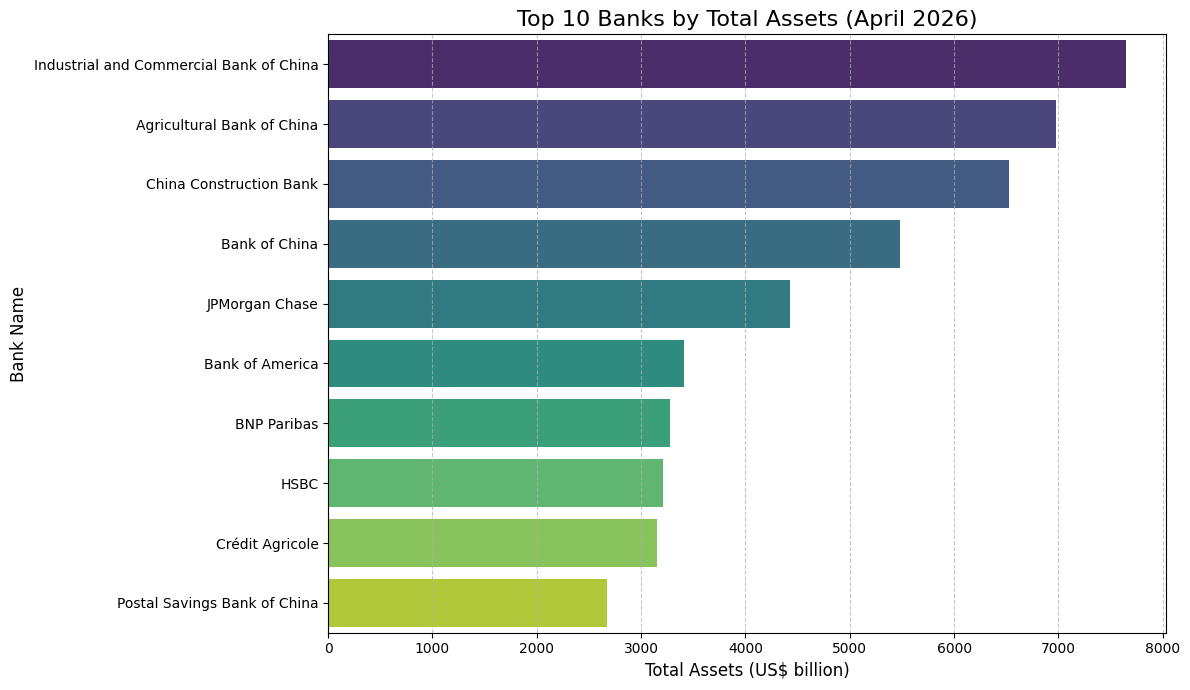

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the DataFrame by 'Total assets' in descending order and get the top 10
top_10_banks = df.sort_values(by='Total assets (April 2026) (US$ billion)', ascending=False).head(10)

# Create the horizontal bar chart
plt.figure(figsize=(12, 7))
sns.barplot(y='Bank name', x='Total assets (April 2026) (US$ billion)', data=top_10_banks, palette='viridis', hue='Bank name', legend=False)

plt.title('Top 10 Banks by Total Assets (April 2026)', fontsize=16)
plt.ylabel('Bank Name', fontsize=12)
plt.xlabel('Total Assets (US$ billion)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7) # Grid on x-axis for horizontal bars
plt.tight_layout()
plt.show()

In [ ]:
correlation = df['Rank'].corr(df['Total assets (April 2026) (US$ billion)'])
print(f"La correlación entre el Ranking y los Activos Totales es: {correlation}")

La correlación entre el Ranking y los Activos Totales es: -0.7540108655294416


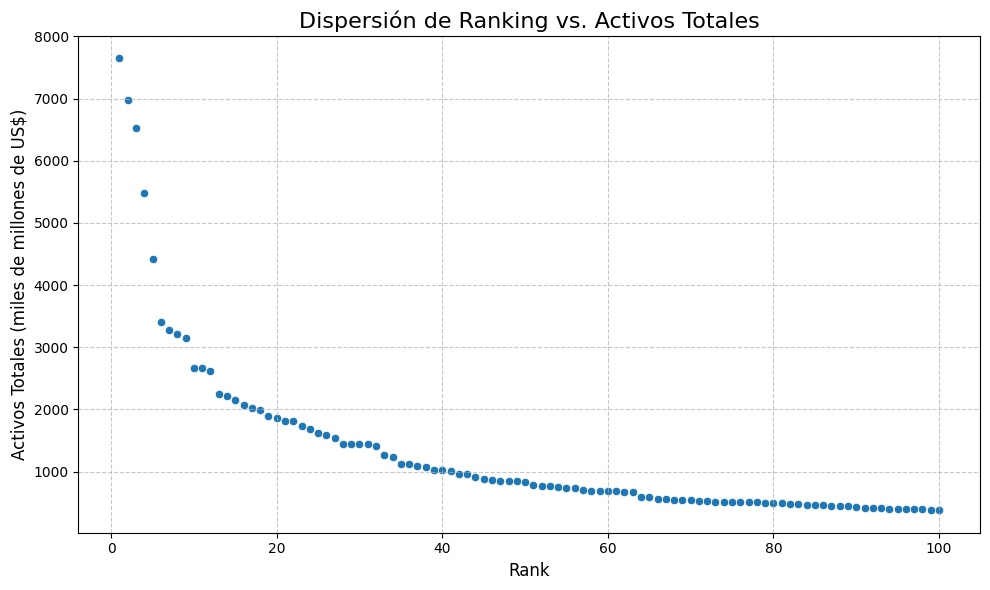

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Rank', y='Total assets (April 2026) (US$ billion)', data=df)
plt.title('Dispersión de Ranking vs. Activos Totales', fontsize=16)
plt.xlabel('Rank', fontsize=12)
plt.ylabel('Activos Totales (miles de millones de US$)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

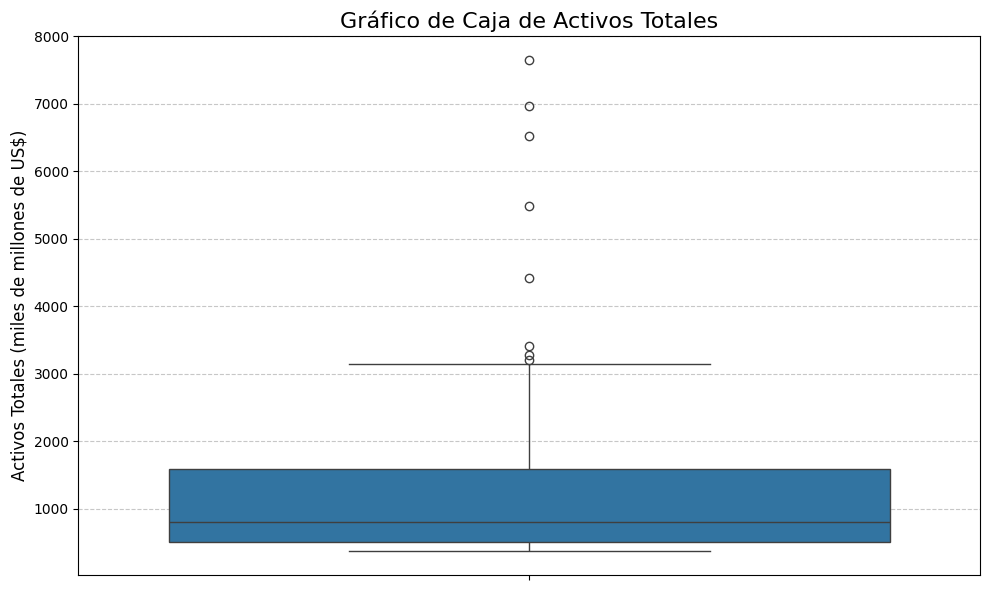

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(y=df['Total assets (April 2026) (US$ billion)'])
plt.title('Gráfico de Caja de Activos Totales', fontsize=16)
plt.ylabel('Activos Totales (miles de millones de US$)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

En este gráfico de caja:

*   La **caja** representa el rango intercuartílico (IQR), que contiene el 50% central de los datos. La línea dentro de la caja es la mediana.
*   Los **"bigotes"** (líneas que se extienden desde la caja) muestran la dispersión de los datos más allá del IQR, generalmente hasta 1.5 veces el IQR desde los cuartiles.
*   Cualquier punto individual que esté **fuera de los bigotes** se considera un **valor atípico (outlier)**. Estos puntos son los que se desvían más de la mayoría de los datos y son los que debemos investigar.

In [ ]:
# Crear un nuevo DataFrame excluyendo los bancos atípicos
df_no_outliers = df[~df['Bank name'].isin(outliers['Bank name'])]

# Calcular la correlación en el nuevo DataFrame sin valores atípicos
correlation_no_outliers = df_no_outliers['Rank'].corr(df_no_outliers['Total assets (April 2026) (US$ billion)'])

print(f"Correlación original (con valores atípicos): {correlation:.3f}")
print(f"Correlación sin valores atípicos: {correlation_no_outliers:.3f}")

print("\nAnálisis:")
if abs(correlation_no_outliers) > abs(correlation):
    print("La correlación es más fuerte (más cercana a -1 o 1) sin los valores atípicos, lo que sugiere que los outliers estaban 'debilitando' la relación lineal.")
elif abs(correlation_no_outliers) < abs(correlation):
    print("La correlación es más débil (más cercana a 0) sin los valores atípicos, lo que podría indicar que los outliers estaban contribuyendo a la relación lineal observada.")
else:
    print("La correlación no cambia significativamente, lo que indica que los outliers no tuvieron un impacto importante en la fuerza de la relación lineal.")

Correlación original (con valores atípicos): -0.754
Correlación sin valores atípicos: -0.904

Análisis:
La correlación es más fuerte (más cercana a -1 o 1) sin los valores atípicos, lo que sugiere que los outliers estaban 'debilitando' la relación lineal.


In [ ]:
Q1 = df['Total assets (April 2026) (US$ billion)'].quantile(0.25)
Q3 = df['Total assets (April 2026) (US$ billion)'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

outliers = df[(df['Total assets (April 2026) (US$ billion)'] > upper_bound) | (df['Total assets (April 2026) (US$ billion)'] < lower_bound)]

print(f"Los límites para identificar valores atípicos son:")
print(f"  Límite Inferior: {lower_bound:.2f} mil millones de US$")
print(f"  Límite Superior: {upper_bound:.2f} mil millones de US$")
print("\nBancos identificados como valores atípicos (outliers):")
display(outliers[['Bank name', 'Total assets (April 2026) (US$ billion)']])

Los límites para identificar valores atípicos son:
  Límite Inferior: -1103.13 mil millones de US$
  Límite Superior: 3212.24 mil millones de US$

Bancos identificados como valores atípicos (outliers):


,Bank name,Total assets (April 2026) (US$ billion)
0,Industrial and Commercial Bank of China,7645.80
1,Agricultural Bank of China,6974.82
2,China Construction Bank,6524.05
3,Bank of China,5484.11
4,JPMorgan Chase,4424.90
5,Bank of America,3411.74
6,BNP Paribas,3279.30
7,HSBC,3212.35


En este gráfico de dispersión, cada punto representa un banco. El eje X muestra el 'Rank' (clasificación) del banco y el eje Y muestra sus 'Activos Totales'.

Dado que la correlación calculada fue de **-0.754** (una correlación negativa fuerte):

*   Deberías observar una **tendencia descendente** de los puntos de datos. Es decir, a medida que el valor del 'Rank' aumenta (moviéndose hacia la derecha en el eje X), los 'Activos Totales' tienden a disminuir (moviéndose hacia abajo en el eje Y).
*   Los puntos no formarán una línea perfecta, pero mostrarán una clara **inclinación hacia abajo**.
*   Esto confirma que los bancos con un **rank más bajo (es decir, clasificados más alto con un número menor en la lista)** tienen una mayor cantidad de activos, mientras que los bancos con un **rank más alto (número mayor)** tienen menos activos.